In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

plt.style.use("ggplot")

In [2]:
# Load cleaned dataset

df = pd.read_csv("../processed/cleaned_youtube_data.csv")

In [3]:
# Display first five rows

df.head()

,category_id,view_count,like_count,comment_count,duration,duration_seconds
0,0.634019,0.029288,243350.0,-0.330080,PT57S,-0.329112
1,0.017250,-0.319920,3393.0,-0.165235,PT7M50S,0.044432
2,0.634019,2.944978,4178447.0,1.003008,PT47S,-0.338157
3,0.428429,0.524317,909386.0,0.162410,PT31S,-0.352628
4,0.634019,-0.219222,44278.0,-0.138177,PT16S,-0.366195


In [4]:
df.describe()

,category_id,view_count,like_count,comment_count,duration_seconds
count,5.840000e+02,5.840000e+02,5.840000e+02,5.840000e+02,5.840000e+02
mean,2.555034e-16,4.866731e-17,2.204846e+05,-1.825024e-17,-1.216683e-17
std,1.000857e+00,1.000857e+00,5.135630e+05,1.000857e+00,1.000857e+00
min,-4.916902e+00,-3.315698e-01,0.000000e+00,-4.471773e-01,-3.806666e-01
25%,-5.995192e-01,-3.278677e-01,1.646000e+03,-4.437668e-01,-3.643862e-01
50%,4.284292e-01,-2.916785e-01,2.214900e+04,-3.871509e-01,-3.395134e-01
75%,6.340188e-01,-8.035010e-02,2.174646e+05,-3.358575e-02,1.842847e-02
max,1.045198e+00,1.351033e+01,4.421091e+06,8.702542e+00,1.513090e+01


In [5]:
# Display dataset information

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   category_id       584 non-null    float64
 1   view_count        584 non-null    float64
 2   like_count        584 non-null    float64
 3   comment_count     584 non-null    float64
 4   duration          584 non-null    str    
 5   duration_seconds  584 non-null    float64
dtypes: float64(5), str(1)
memory usage: 27.5 KB


# Distribution of Numerical Features

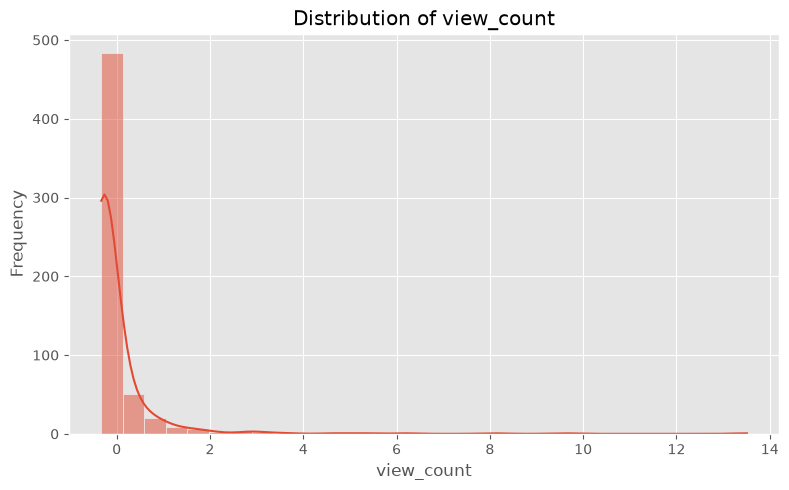

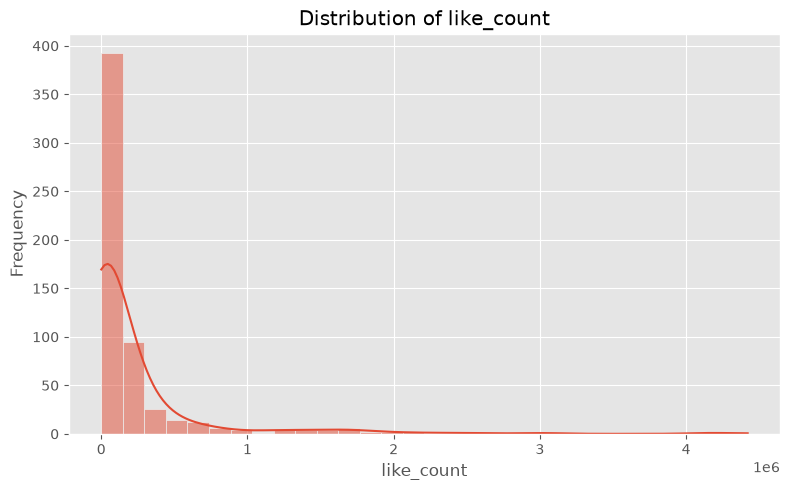

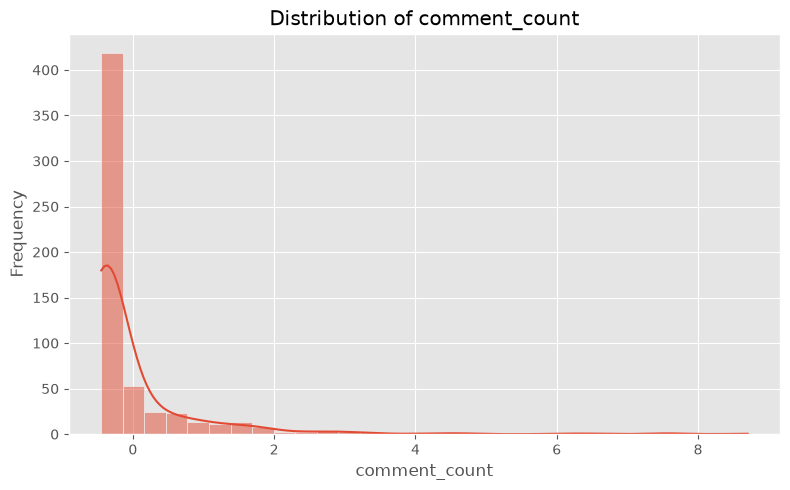

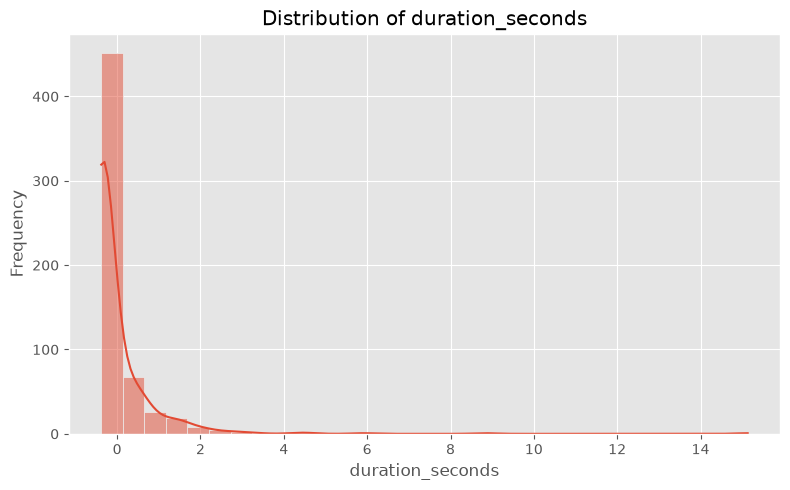

In [6]:
numerical_features = [

    "view_count",

    "like_count",

    "comment_count",

    "duration_seconds"

]

for column in numerical_features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(f"../images/{column}_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

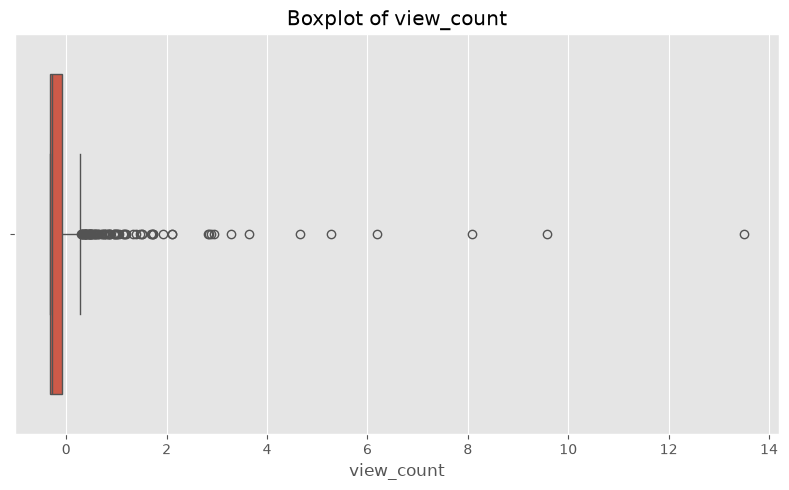

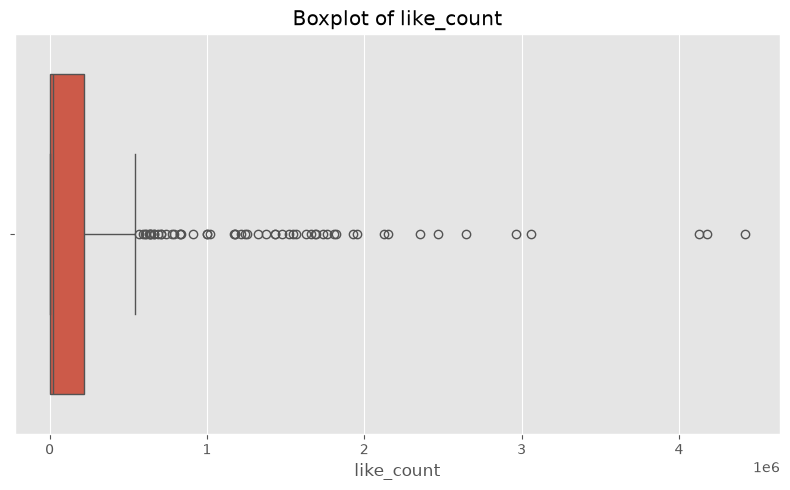

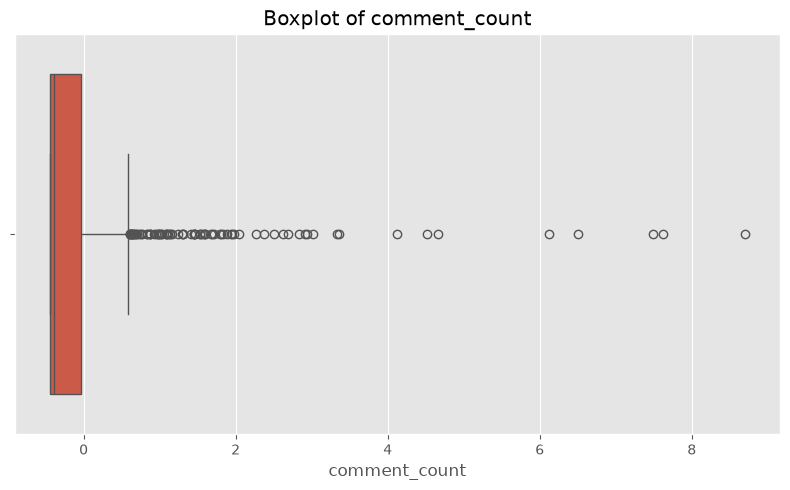

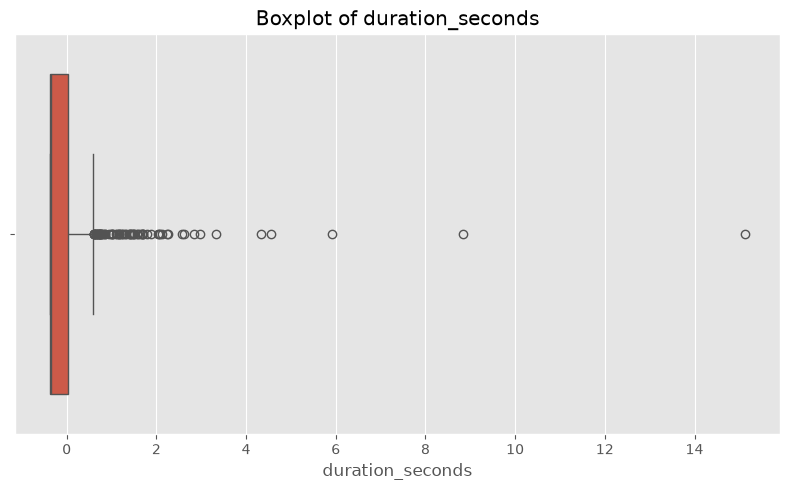

In [7]:
# Boxplots of numerical features

for column in numerical_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.tight_layout()

    plt.savefig(f"../images/{column}_boxplot.png", dpi=300, bbox_inches="tight")

    plt.show()

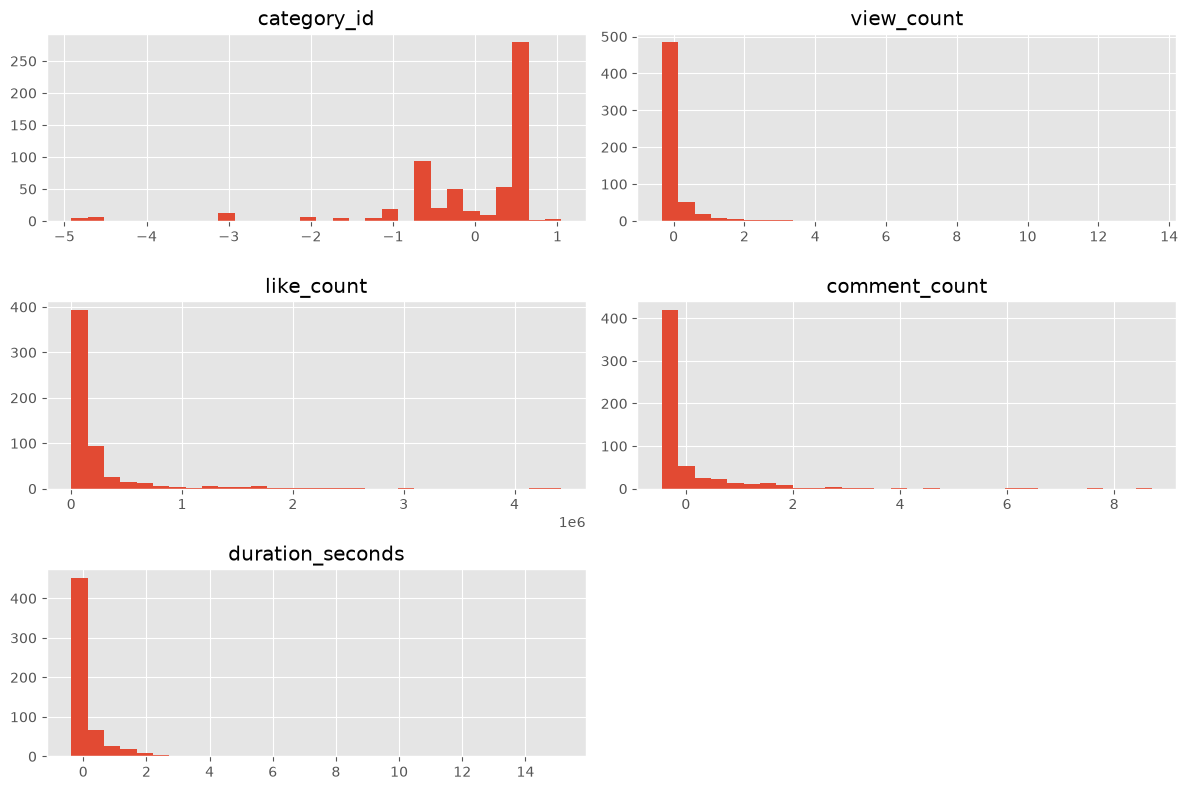

In [8]:
# Histograms of all numerical columns

df.hist(figsize=(12, 8), bins=30)
plt.savefig(
    "../images/histograms.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

In [9]:
# Correlation matrix

correlation_matrix = df.corr(numeric_only=True)

display(correlation_matrix)

,category_id,view_count,like_count,comment_count,duration_seconds
category_id,1.000000,-0.109043,0.062505,0.049770,0.081169
view_count,-0.109043,1.000000,0.699624,0.417286,-0.062330
like_count,0.062505,0.699624,1.000000,0.399754,-0.106740
comment_count,0.049770,0.417286,0.399754,1.000000,0.128341
duration_seconds,0.081169,-0.062330,-0.106740,0.128341,1.000000


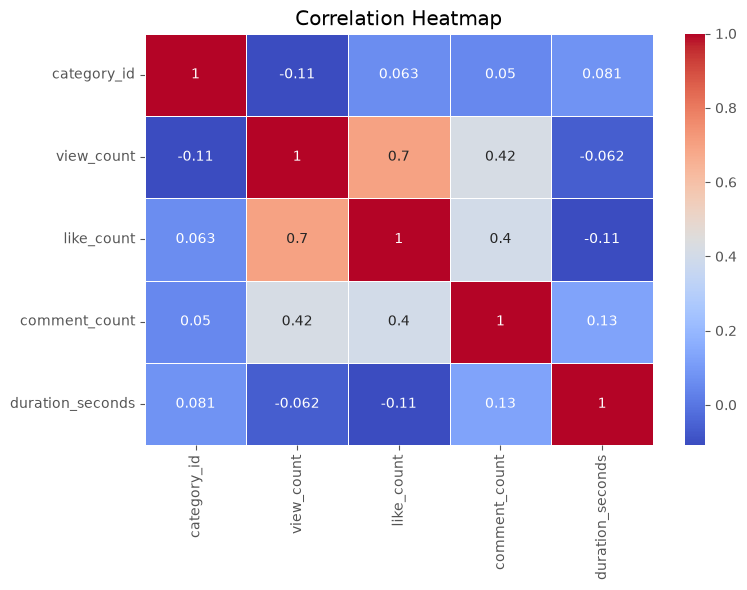

In [10]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(

    correlation_matrix,

    annot=True,

    cmap="coolwarm",

    linewidths=0.5

)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(f"../images/{column}_correlation_heatmap.png", dpi=300)

plt.show()

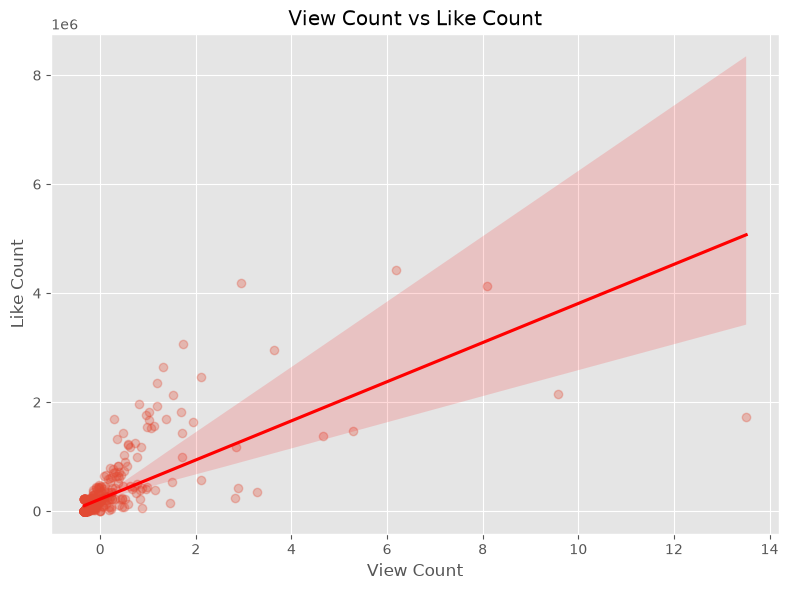

In [11]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="view_count",
    y="like_count",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("View Count vs Like Count")

plt.xlabel("View Count")
plt.ylabel("Like Count")

plt.tight_layout()

plt.savefig(
    "../images/video_duration_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

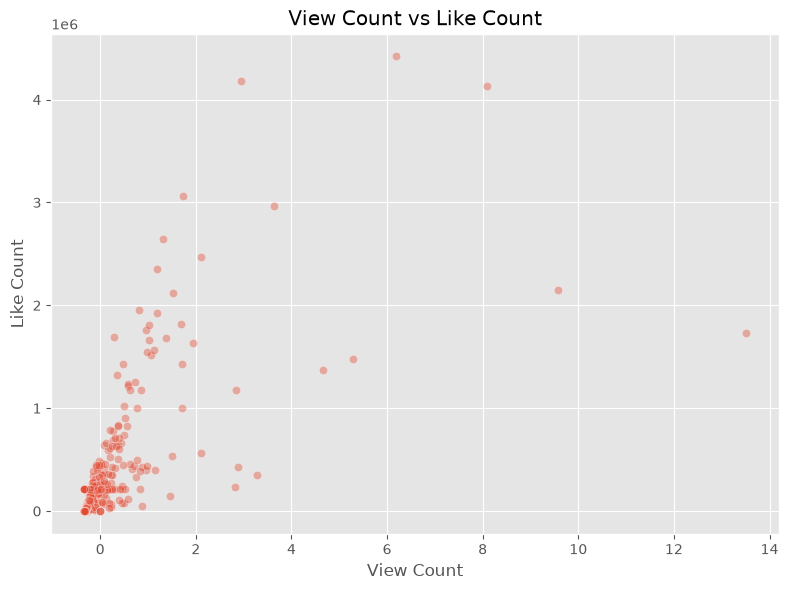

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="view_count",
    y="like_count",
    alpha=0.4
)
plt.title("View Count vs Like Count")
plt.xlabel("View Count")
plt.ylabel("Like Count")

plt.tight_layout()

plt.savefig(
    "../images/view_count_vs_like_count.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

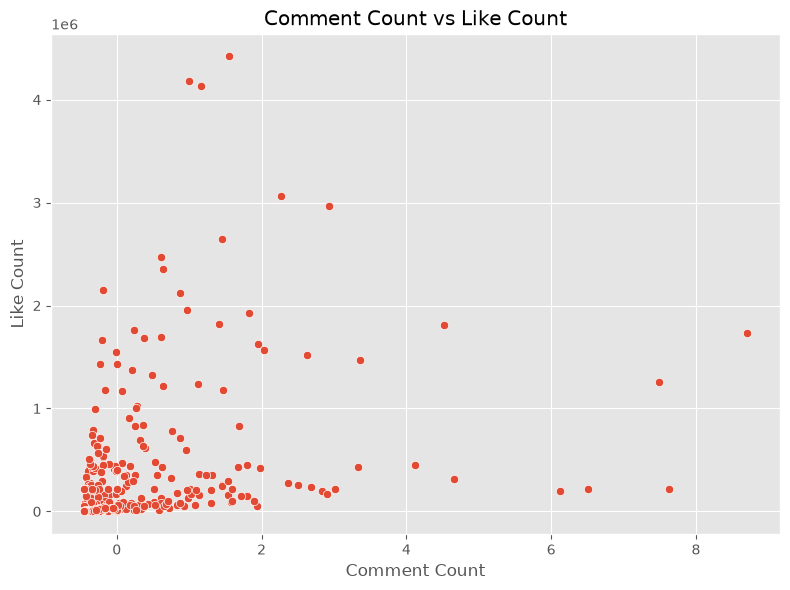

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="comment_count",
    y="like_count",
)

plt.title("Comment Count vs Like Count")
plt.xlabel("Comment Count")

plt.ylabel("Like Count")

plt.tight_layout()

plt.savefig(
    "../images/comment_count_vs_like_count.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

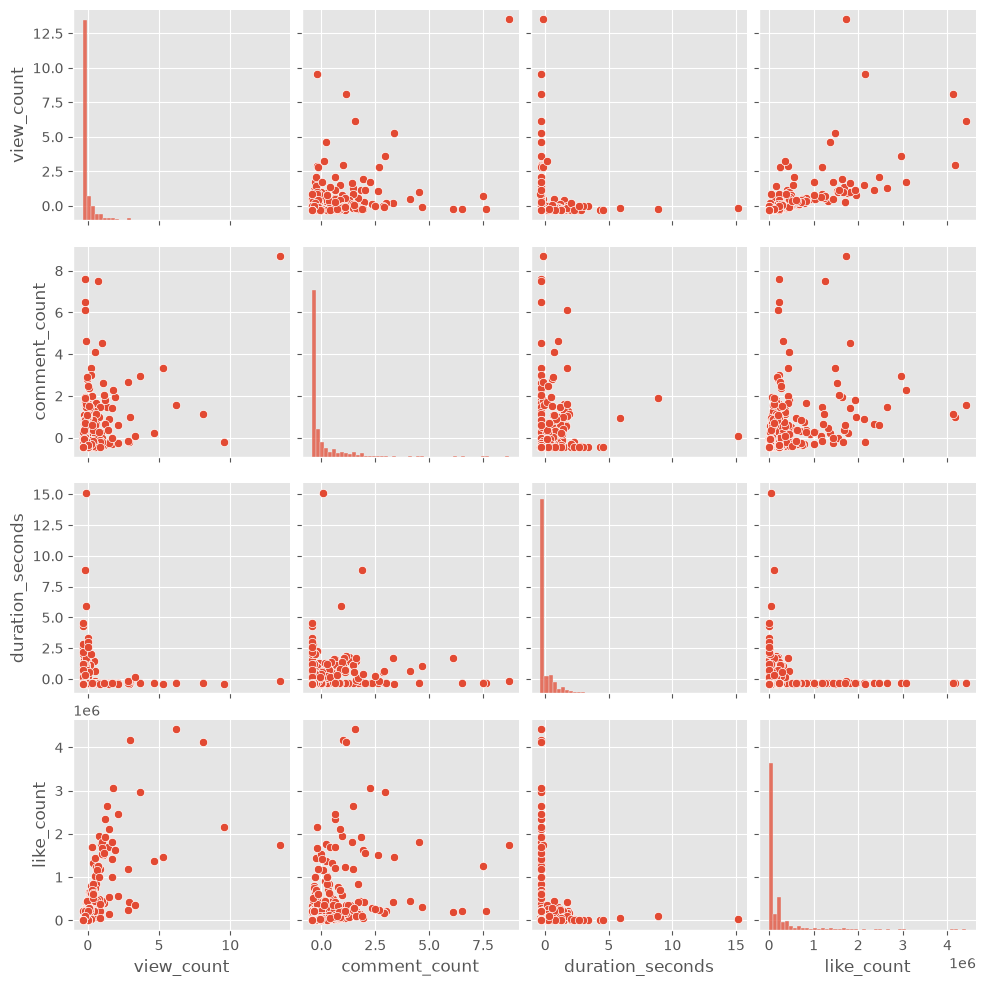

In [14]:
selected_columns = [
    "view_count",
    "comment_count",
    "duration_seconds",
    "like_count",
]

sns.pairplot(df[selected_columns])
plt.savefig(
    "../images/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [1]:
# Correlation with target variable

target_correlation = correlation_matrix["avg_view_percentage"].sort_values(ascending=False)

target_correlation

NameError: name 'correlation_matrix' is not defined

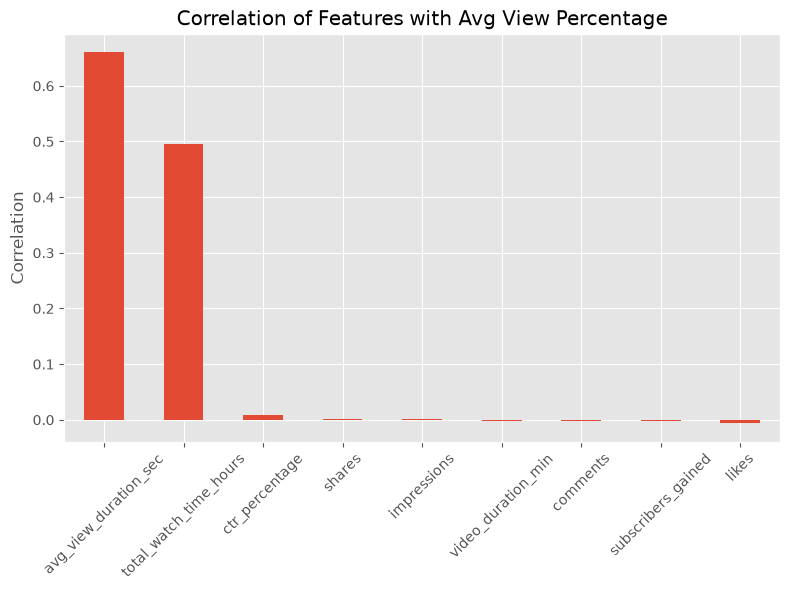

In [ ]:
plt.figure(figsize=(8,6))

target_correlation.drop("avg_view_percentage").plot(kind="bar")

plt.title("Correlation of Features with Avg View Percentage")

plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/target_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()